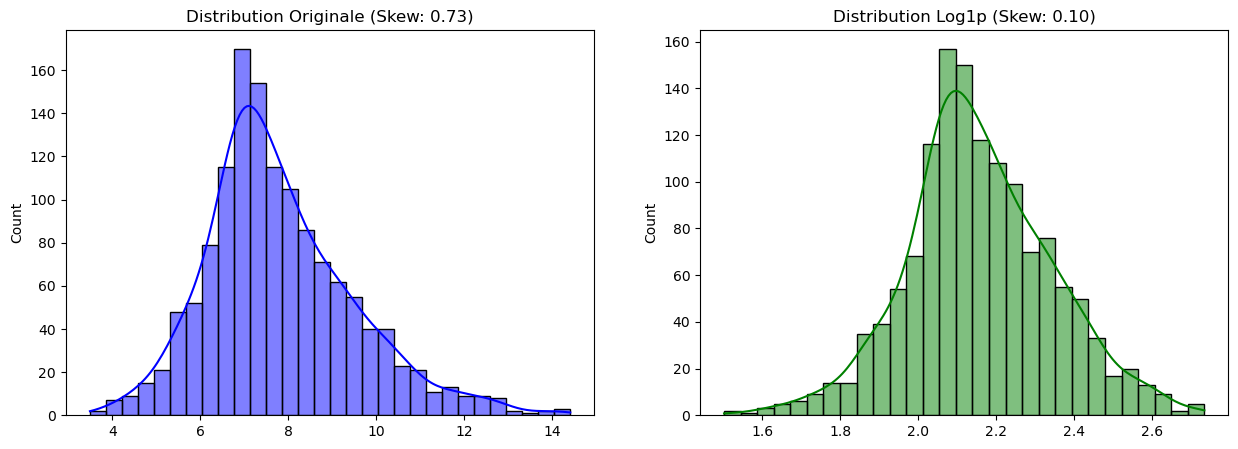

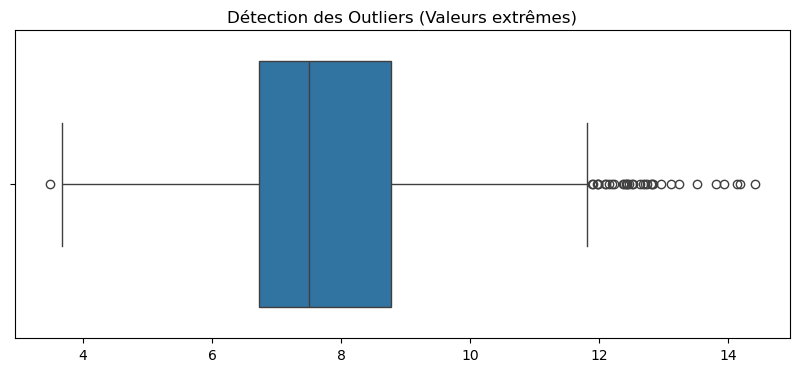

Skewness Originale : 0.73
Skewness Log        : 0.10

❌ VERDICT : Le Log Target n'est pas forcément nécessaire.
La distribution originale est déjà assez équilibrée.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Chargement de la target
y = pd.read_csv("../features/global_features/y_train.csv")
# Assure-toi de prendre la colonne numérique (ex: 'score_popularite')
target_col = y.columns[1] if 'video_id' in y.columns else y.columns[0]
y_values = y[target_col].values

# 2. Création de la version Log
y_log = np.log1p(y_values)

# 3. Analyse Visuelle
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution Originale
sns.histplot(y_values, kde=True, ax=axes[0], color='blue')
axes[0].set_title(f"Distribution Originale (Skew: {pd.Series(y_values).skew():.2f})")

# Distribution Log
sns.histplot(y_log, kde=True, ax=axes[1], color='green')
axes[1].set_title(f"Distribution Log1p (Skew: {pd.Series(y_log).skew():.2f})")

plt.show()

# 4. Analyse des Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=y_values)
plt.title("Détection des Outliers (Valeurs extrêmes)")
plt.show()

# 5. Verdict Automatique
skew_orig = abs(pd.Series(y_values).skew())
skew_log = abs(pd.Series(y_log).skew())

print(f"Skewness Originale : {skew_orig:.2f}")
print(f"Skewness Log        : {skew_log:.2f}")

if skew_log < skew_orig and skew_orig > 0.75:
    print("\n✅ VERDICT : Le Log Target est RECOMMANDÉ.")
    print("La distribution est asymétrique et le log la rend plus 'normale' (gaussienne).")
    print("Cela aidera tes modèles à moins souffrir des vidéos ultra-populaires.")
else:
    print("\n❌ VERDICT : Le Log Target n'est pas forcément nécessaire.")
    print("La distribution originale est déjà assez équilibrée.")